In [1]:
from pathlib import Path

import aw
from aw import reload
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import job_search.ai as ai
from job_search.config import VIEW_JOB_HTTPS, P_stem
import job_search.config as conf
import job_search.dataset as ds
# import job_search.jobs as jobs
import job_search.jobs as jb
import job_search.utils as utils
from job_search.jobs import COLS, cmask, disp

In [2]:
jobs_df = jb.load_jobs(overwrite=True)#.rename(columns={'title': 'title_', 'position': 'position_'})
jobs_mar = jobs_df.query('mar')
jobs2026 = jb.load_jobs2026()

Saving: C:\Users\Alex\Dev\job-search\data\cache\jobs.parquet


In [3]:
JDF_COLS = ['days', 'title_', 'location', 'salary', 'onsite', 'full_time', 'company', 'yoe', '_hash', '_len', 'hours', 'position_', 'bay']
jdf = jb.load_jdf().rename(columns={'hash': '_hash', 'title': 'title_', 'position': 'position_'})[JDF_COLS]
jdf_hashes = jdf['_hash'].pipe(set)
# df = jobs_df.query('_hash in @jdf_hashes').reset_index(drop=True)
df = pd.merge(jdf[JDF_COLS], jobs_df, on='_hash', how='left')
# df['company_name'] = df['company_name'].fillna(df['company'])
# hash2position = dict(zip(jobs_df['_hash'], jobs_df['position']))

Date range:  Jan 02, 2026 to Mar 31, 2026 (88 days)
Mean date:   Feb 13, 2026
Median date: Feb 10, 2026


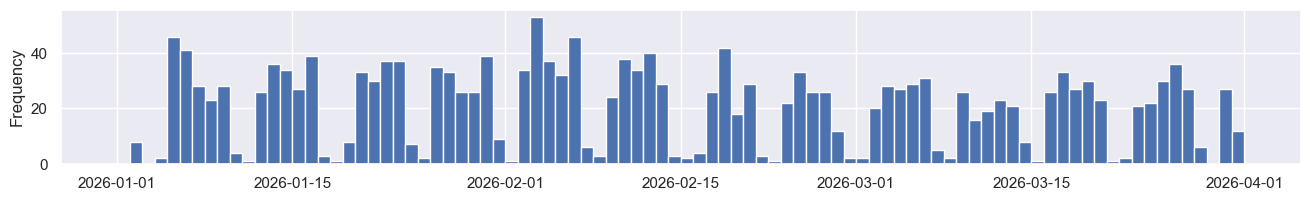

In [4]:
import job_search.canes_visuals as cv
sns.set_theme()
_, ax = plt.subplots(figsize=(16,2))
cv.plot_hist_date(jobs2026['estimated_publish_date'], freq='D', verbose=True, ax=ax)

## EDA

In [20]:
from job_search.config import VIEW_JOB_HTTPS
from textwrap import dedent
_jobs_df = jobs_df.query('mar')
mask = cmask('protein')
mask = mask.reindex(_jobs_df.index)
for title, comp, hash in _jobs_df[mask][['title', 'company_name', '_hash']].pipe(aw.itertuples):
    print(dedent(f"""
        {title}
        @ {comp}
        {VIEW_JOB_HTTPS}{hash}"""))


Senior Scientist, Bio AI
@ Earli
https://hiring.cafe/viewjob/sz9aftvd6zie5aza

ML Platform / MLOps Engineer
@ Profluent
https://hiring.cafe/viewjob/iihqs2wa36854qe0

AI Research Engineer
@ Xaira Therapeutics
https://hiring.cafe/viewjob/kf0xfg2delhdntyn

Data Infrastructure Engineer
@ Glyphic Biotechnologies
https://hiring.cafe/viewjob/94hha4gv9pxwxtou

Scientist I, AI Engineer
@ Frontier Medicines
https://hiring.cafe/viewjob/8ydq5o1xum7t1m3m

BioMedical AI Research Engineer
@ Xaira Therapeutics
https://hiring.cafe/viewjob/auc02qkvyougmn9w


In [11]:
jb.disp(jobs_df.query('mar'), 'protein', 5, llm=False)

N,Total,%
6,581,1.0


6 of 6: https://hiring.cafe/viewjob/auc02qkvyougmn9w


,2862
company_name,Xaira Therapeutics
title,BioMedical AI Research Engineer
estimated_publish_date,2026-03-31 20:14:54
requirements_summary,"Design and deploy agentic AI systems for biomedical data integration and discovery; strong ML, LLMs, Python, and biomedical data experience."
job_category,Research and Development (R&D)
workplace_type,Onsite
formatted_workplace_location,"South San Francisco, California, United States"
technical_tools,['Python' 'PyTorch' 'JAX' 'TensorFlow' 'Knowledge Graphs' 'LLMs']
role_activities,['design architectures' 'build agents' 'integrate data']
seniority_level,Mid Level


In [158]:
jb.disp(jobs_df.query('mar'), 'real-?world data', 3, llm=True)
# jobs.disp(jobs_df.query('feb'), 'dbt')

N,Total,%
7,566,1.2


4 of 7: https://hiring.cafe/viewjob/ueblett9js51emdg


**Top 7 Essential (Domain Area, Expertise, Soft Skills):**  
- **Domain Area:** Fintech, Payments, Risk & Compliance (with focus on Consumer, SMB, and Enterprise verticals)  
- **Expertise:** Advanced analytics, data modeling, machine learning, ETL pipelines, A/B testing  
- **Technical Skills:** Proficiency in SQL, Python, BigQuery, Tableau, Power BI, Jupyter, Hadoop/Hive  
- **Core Function:** End-to-end ownership of data science projects from ideation to delivery  
- **Business Impact:** Ability to translate complex data into actionable insights for leadership and cross-functional teams  
- **Collaboration:** Strong partnership with Product, Risk, Compliance, and Business teams across global operations  
- **Soft Skills:** Exceptional communication, data storytelling, and influence in ambiguous, fast-paced environments  

**Top 7 Nice-to-Haves:**  
- Experience in Second Line of Defense or Financial Crimes  
- Background in banking or regulatory environments  
- Experience building executive dashboards and driving data-informed decisions at scale  
- Track record of mentoring junior data scientists and fostering team growth  
- Exposure to cross-border payments or global compliance challenges  
- Familiarity with agentic or identity-based systems in payment platforms  
- Passion for product thinking, experimentation, and innovation in dynamic environments

,2634
company_name,PayPal
title,Staff Data Scientist
estimated_publish_date,2026-03-20 00:00:00
requirements_summary,5+ years of experience in analytics/data science; strong SQL and Python; experience with BI tools and data pipelines.
job_category,Data and Analytics
workplace_type,Hybrid
formatted_workplace_location,Austin or San Jose
technical_tools,['SQL' 'Python' 'BigQuery' 'Tableau' 'Power BI' 'Looker']
role_activities,['Lead projects' 'Develop models' 'Analyze data']
seniority_level,Senior Level


In [6]:
print(ai.load_resume38(verbose=False))

**Data Scientist**
Full-stack Data Scientist with 5+ years of experience delivering real-world insights and solutions end-to-end from ideation to deployment in the healthcare and technology sectors. Expansive skill set with a strong focus on AI, machine learning, natural language processing, and software engineering. Enthusiastic collaborator, working with stakeholders to support data-driven decision-making and partnering with cross-functional teams to productionize machine learning models. Passionate about solving real business challenges and delighting end users.

## **SKILLS**

- **Languages and Programming:** Python, SQL, R, JavaScript, Java, C++
- **Python for Data Science:** Pandas, NumPy, Scikit-learn, PyTorch, Jupyter Notebook
- **Visualization and Communication:** Plotly, Matplotlib, Streamlit, Figma, stakeholder reporting
- **Statistical Modeling:** Experimental design, Propensity score matching, Causal inference, Hypothesis testing
- **Machine Learning:** Regression, SVM, Ra

In [7]:
jobs.hash2md("p0w266aywbqx8boy", verbose=True)

**Company Description:**

**Department:** DataSF  
**Job class:** 1043 Senior Data Engineer  
**Salary range:** $153,686/year - $193,388/year   
**Role type:** Permanent Exempt  
**Hours:** Full-time. The department has a hybrid work schedule.

**About:**  
Permanent Exempt: This is an Exempt position excluded by the Charter from the competitive Civil Service examination process, pursuant to the City and County of San Francisco, Charter Section 10.104. It is considered "at will" and shall serve at the discretion of the Appointing Officer.    
  
Application Opening: **Monday, February 23, 2026**  
Application Closing: Interested candidates are encouraged to apply as soon as possible, as this job announcement will close at any time, but not earlier than **Sunday, March 2, 2026 at 11:59pm PST**

**As part of the application process, you must also complete a Supplemental Questionnaire using this link by the filing deadline: <https://forms.office.com/g/PgvQyRjYdX>**

**The Office of the Ci

In [25]:
jobs.disp(jobs_df.query('feb'), 'datasf')

N,Total,%
1,796,0.1


1 of 1: https://hiring.cafe/viewjob/p0w266aywbqx8boy


,431
company_name,City and County of San Francisco
title,Senior Data Engineer (1043) - DataSF
estimated_publish_date,2026-02-23 20:05:04.575000
requirements_summary,"3+ years data engineering experience; strong SQL, data warehousing, ETL/ELT, cloud platforms; able to collaborate with cross-functional teams; willingness to work in the public sector."
job_category,Data and Analytics
workplace_type,Hybrid
formatted_workplace_location,"San Francisco, California, United States"
technical_tools,['Snowflake' 'BigQuery' 'Databricks' 'dbt' 'Python' 'Terraform' 'Airflow' 'Kafka']
role_activities,['build pipelines' 'monitor health' 'collaborate teams']
seniority_level,Mid Level


<div style="font-size:16px;max-width:45rem;margin:0 auto;">**Company Description:**

**Department:** DataSF  
**Job class:** 1043 Senior Data Engineer  
**Salary range:** $153,686/year - $193,388/year   
**Role type:** Permanent Exempt  
**Hours:** Full-time. The department has a hybrid work schedule.

**About:**  
Permanent Exempt: This is an Exempt position excluded by the Charter from the competitive Civil Service examination process, pursuant to the City and County of San Francisco, Charter Section 10.104. It is considered "at will" and shall serve at the discretion of the Appointing Officer.    
  
Application Opening: **Monday, February 23, 2026**  
Application Closing: Interested candidates are encouraged to apply as soon as possible, as this job announcement will close at any time, but not earlier than **Sunday, March 2, 2026 at 11:59pm PST**

**As part of the application process, you must also complete a Supplemental Questionnaire using this link by the filing deadline: <https://forms.office.com/g/PgvQyRjYdX>**

**The Office of the City Administrator**and its 25+ divisions and departments operate core internal and public-facing services in San Francisco.     
  
**The Office of the City Administrator’s Mission and Vision**  
Our vision is to lead the nation in public administration and to enable City departments to effectively deliver critical public services. We aim to help the city run better, to connect San Francisco residents and constituents to the vital public services they seek, and to create a meaningful and diverse work culture that is the place of choice for people who are invested in a career in public service.

We are committed to ensuring that City services are inclusive, efficient, equitable, and culturally competent for San Franciscans of all races, ethnic backgrounds, religions, and sextual orientations. This commitment requires comprehensive review and thorough analysis of existing practices and policies to remove barriers to real inclusion. We are also committed to ensuring that we have a safe, equitable, and inclusive workplace for individuals of all races. This includes creating opportunities for hiring, promotion, training, and development, for all employees, including but not limited to, Black, Indigenous, and people of color (BIPOC).

To learn more about our departments, divisions, and programs, visit:  <https://sf.gov/departments/city-administrator>

**About DataSF:**

Want to build robust and scalable data infrastructure to power data-driven City services? Join the [DataSF](http://sf.gov/data) team to empower and expand the use of data in government!

**Company Description**

DataSF’s mission is to transform the way San Francisco works with data. We believe that data, when harnessed effectively, can improve transparency, resident engagement, and government performance. We are committed to removing barriers and making it easier for all people to access services and knowledge, and we actively seek team members whose diverse life experiences reflect the residents we serve.

**Job Description:**

DataSF is seeking a Senior Data Engineer with 3+ years of experience to join our growing team. Reporting to the Principal Data Engineer, you will be instrumental in designing, building, and maintaining the City's data infrastructure, enabling robust data pipelines and reliable data access for analytical and operational needs. This is an exciting position for someone eager to apply advanced data engineering techniques to complex urban challenges, contributing directly to San Francisco's commitment to efficient, equitable, and ethical service delivery.

Learn more about DataSF’s recent work on [our blog](https://datasf.substack.com/). If you are an entrepreneurial and passionate data enthusiast, join our team to improve government through good use of data!

**Essential duties include, but are not limited to, the following:**

* **Platform Administration**: Manage our central <span style="color: rebeccapurple">Snowflake</span> data warehouse, including access control, security policies, resource monitoring, performance tuning, and cost optimization. Administer our platform with a focus on data democratization and accessibility, while protecting privacy and security.
* **Pipeline Developmen**t: Build and maintain scalable and resilient pipelines to ingest and structure data from diverse sources. Design infrastructure to support both streaming and batch processes, and both structured and unstructured data sources.
* **Infrastructure as Code (IaC)**: Use <span style="color: rebeccapurple">Terraform</span> to define, deploy, and manage data infrastructure, ensuring our pipelines are reproducible, version-controlled, and production-ready.
* **Best Practices & Innovation**: Champion and implement best practices for documentation, data modeling, warehouse architecture, SQL optimization, and testing. Think creatively to find new ways to improve our data platform's capabilities and efficiency. Provide guidance to department partners on data engineering best practices.
* **Collaboration**: Work closely with data scientists, analysts, product managers, software engineers, and nontechnical stakeholders in diverse domains to understand data requirements and build solutions that meet their needs.
* **Monitoring & Support**: Proactively monitor the health of the data platform and pipelines, troubleshoot issues, and ensure high standards of data quality and availability.

**Desirable Qualifications**

* **Technical Knowledge**
  + Hands-on experience administering and developing on managed cloud data platforms such as <span style="color: rebeccapurple">Snowflake</span>, <span style="color: rebeccapurple">BigQuery</span>, or <span style="color: rebeccapurple">Databricks</span>.
  + Demonstrated expertise in writing advanced, performant SQL, and using tools like <span style="color: rebeccapurple">dbt</span> for SQL-based data transformation and modeling.
  + Strong programming skills in <span style="color: rebeccapurple">Python</span> (with libraries like pandas, PySpark) for data processing and automation.
  + Proficiency with an Infrastructure as Code tool, with a preference for <span style="color: rebeccapurple">Terraform</span>.
  + Experience building and deploying data pipelines using orchestration tools like Azure Data Factory, <span style="color: rebeccapurple">Airflow</span>, Dagster, or similar technologies.
  + Deep understanding of data warehousing concepts, data modeling, and modern ELT principles.
  + Understanding of data governance, data security, and data privacy principles.
  + Experience with real-time data streaming technologies (e.g., <span style="color: rebeccapurple">Kafka</span>, Kinesis, Snowpipe).
  + Experience deploying and managing data pipelines for machine learning models.
* **Collaboration and Communication Skills**
  + Strong problem-solving skills with ability to design practical and effective data solutions
  + Excellent verbal and written communication skills, includingthe ability to explain technical concepts to non-technical stakeholders
  + A collaborative mindset with enthusiasm to work across diverse, cross-functional teams
* **Mission Alignment**
  + Commitment to equity, transparency, and ethical data use
  + Passion for public service and using data to improve government services
  + Empathy for San Francisco’s diverse communities and a drive to make data and services and more accessible for SF residents
  + Interest or experience in public sector data or social impact work

**Qualifications:**

**Education**:  
An associate degree in computer science, computer engineering, information systems, or a closely related field from an accredited college or university OR its equivalent in terms of total course credits/units [i.e., at least sixty (60) semester or ninety (90) quarter credits/units with a minimum of twenty (20) semester or thirty (30) quarter credits/units in one of the fields above or a closely-related field].

**Experience**:  
Three (3) years of experience analyzing, installing, configuring, enhancing, and/or maintaining the components of an enterprise network.

**Substitution**:  
Additional experience as described above may be substituted for the required degree on a year-for-year basis (up to a maximum of two (2) years). One (1) year is equivalent to thirty (30) semester units/ forty-five (45) quarter units with a minimum of 10 semester / 15 quarter units in one of the fields above or a closely related field.

Completion of the 1010 Information Systems Trainee Program may be substituted for the required degree.

**Verification:  
Please make sure it is clear in your application exactly how you meet the minimum qualifications.** Applicants will be required to submit verification of qualifying education and experience during the recruitment and selection process. For information on how to verify experience and/or education requirements, including verifying foreign education credits or degree equivalency, please visit [Verification of Experience and/or Education.](https://sfdhr.org/information-about-hiring-process#verification:~:text=Verification%20of%20Experience%20and/or%20Education)

**Note:** Falsifying one’s education, training, or work experience or attempted deception on the application may result in disqualification for this and future job opportunities with the City and County of San Francisco.

*Applicants must meet the minimum qualification requirement by the final application deadline unless otherwise noted.*

**Additional Information:**

**Selection Procedures**  
The selection process will include evaluation of applications in relation to minimum requirements and assessment of candidates’ job-related knowledge, skills and abilities. Depending on the number of applicants, the Department may establish and implement additional screening mechanisms to evaluate candidate qualifications. This typically includes an oral interview and/or a written or performance exercise.

If this becomes necessary, only those applicants whose qualifications most closely meet the Department needs will be invited to continue in the selection process. Applicants meeting the minimum requirements are not guaranteed advancement in the selection process.  
  
To find Departments which use this classification, please see: <https://sfdhr.org/sites/default/files/documents/Forms-Documents/Position-Counts-by-Job-Codes-and-Department-FY-2022-23.pdf>.

**Additional Information Regarding Employment with the City and County of San Francisco:**

* [Information About The Hiring Process](https://sfdhr.org/information-about-hiring-process)
* [Conviction History](http://sfdhr.org/conviction-history-faq)
* [Employee Benefits Overview](https://sfdhr.org/benefits-overview)
* [Equal Employment Opportunity](https://sfdhr.org/equal-employment-opportunity)
* [Disaster Service Worker](https://sfdhr.org/disaster-service-workers)
* [ADA Accommodation](https://sfdhr.org/information-about-hiring-process#applicantswithdisabilities)
* [Veterans Preference](http://sfdhr.org/information-about-hiring-process#veteranspreference)
* [Right to Work](https://sfdhr.org/information-about-hiring-process#identification)
* [Copies of Application Documents](https://sfdhr.org/information-about-hiring-process#copies)
* [Diversity Statement](https://sfdhr.org/information-about-hiring-process#diversitystatement)

**How to Apply:**

**Applications for City and County of San Francisco jobs are only accepted through an online process.**Visit [https://careers.sf.gov](https://careers.sf.gov/) and begin the application process.

* Interested candidates are encouraged to apply as soon as possible, as this job announcement will close at any time, but not before **Sunday, March 1, 2026**(11:59 PM, PST)
* Select the **"Apply Now"** button and follow instructions on the screen
* **You MUST include a cover letter.**
* **As part of the application process, you must also complete a Supplemental Questionnaire using this link: <https://forms.office.com/g/PgvQyRjYdX>**

For best practices on the application process, please visit [Apply for Jobs in the City and County of San Francisco Best Practices Guide.](https://sf.gov/sites/default/files/2022-04/Best%20Practices%20Guide%20-%20%20Applying%20for%20Jobs%20in%20CCSF%20-%20final.pdf) Applicants may be contacted by email about this announcement and, therefore, it is their responsibility to ensure that their registered email address is accurate and kept up-to-date. Also, applicants must ensure that email from CCSF is not blocked on their computer by a spam filter. To prevent blocking, applicants should set up their email to accept CCSF mail from the following addresses @sfgov.org, @sfdpw.org, @sfport.com, @flysfo.com, @sfwater.org, @sfdph.org, @asianart.org, @sfmta.com, @sfpl.org, @dcyf.org, @first5sf.org, @famsf.org, @ccsf.edu, @smartalerts.info, and @smartrecruiters.com).

Applicants will receive a confirmation email that their online application has been received in response to every announcement for which they file. Applicants should retain this confirmation email for their records. **Failure to receive this email means that the online application was not submitted or received.**

All your information will be kept confidential according to EEO guidelines.

**HR Analyst Information:**If you have any questions regarding this recruitment or application process, please contact Connie Poon at Connie.Poon@SFGov.org

**Condition of Employment:**

The City and County of San Francisco encourages women, minorities and persons with disabilities to apply. Applicants will be considered regardless of their sex, race, age, religion, color, national origin, ancestry, physical disability, mental disability, medical condition (associated with cancer, a history of cancer, or genetic characteristics), HIV/AIDS status, genetic information, marital status, sexual orientation, gender, gender identity, gender expression, military and veteran status, or other protected category under the law.

The City and County of San Francisco encourages women, minorities and persons with disabilities to apply. Applicants will be considered regardless of their sex, race, age, religion, color, national origin, ancestry, physical disability, mental disability, medical condition (associated with cancer, a history of cancer, or genetic characteristics), HIV/AIDS status, genetic information, marital status, sexual orientation, gender, gender identity, gender expression, military and veteran status, or other protected category under the law.

The City and County of San Francisco encourages women, minorities and persons with disabilities to apply. Applicants will be considered regardless of their sex, race, age, religion, color, national origin, ancestry, physical disability, mental disability, medical condition (associated with cancer, a history of cancer, or genetic characteristics), HIV/AIDS status, genetic information, marital status, sexual orientation, gender, gender identity, gender expression, military and veteran status, or other protected category under the law.</div>

In [39]:
rwd_mask = jobs.text_mask('rwd|real.?world data')
# rwd_mask = jobs.cmask('rwd|real[- ]world data')
# jobs.perc(rwd_mask)
jobs.disp(jobs_df.query('estimated_publish_date >= "2026-03-01"'), rwd_mask)
# jobs.disp(jobs_df, rwd_mask)

N,Total,%
1,178,0.6


1 of 1: https://hiring.cafe/viewjob/ocqdfrcxe5snu53i


,999
company_name,Hewlett Packard Enterprise
title,AI and Machine Learning Engineer
estimated_publish_date,2026-03-08 00:00:00
requirements_summary,"2-4 years of experience in AI/ML; strong Python/Java/R; ML model development, data preprocessing, and deployment capabilities."
job_category,Engineering
workplace_type,Hybrid
formatted_workplace_location,"San Francisco, California, United States"
technical_tools,['Python' 'R' 'Java' 'TensorFlow' 'PyTorch' 'scikit-learn' 'Keras' 'SQL']
role_activities,['Design models' 'Prepare data' 'Train models']
seniority_level,Mid Level


<div style="font-size:16px;max-width:45rem;margin:0 auto;"><span style="color: rebeccapurple">AI</span> and Machine Learning EngineerThis role has been designed as ‘Hybrid’ with an expectation that you will work on average 2 days per week from an HPE office.

**Who We Are:**

Hewlett Packard Enterprise is the global edge-to-cloud company advancing the way people live and work. We help companies connect, protect, analyze, and act on their data and applications wherever they live, from edge to cloud, so they can turn insights into outcomes at the speed required to thrive in today’s complex world. Our culture thrives on finding new and better ways to accelerate what’s next. We know varied backgrounds are valued and succeed here. We have the flexibility to manage our work and personal needs. We make bold moves, together, and are a force for good. If you are looking to stretch and grow your career our culture will embrace you. Open up opportunities with HPE.

**Job Description:**

***Job Family Definition:***

Develops and programs integrated software algorithms to structure, analyze and leverage structured and unstructured data in product and systems applications. Can work with large scale computing frameworks, data analysis systems, and modeling environments.  
  
Uses machine learning and statistical modeling techniques to improve product/system performance, data management, quality, and accuracy. Formulates descriptive, diagnostic, predictive and prescriptive insights/algorithms and translates technical specifications into code. Applies, optimizes and scales deep learning technologies and algorithms to give computers the capability to visualize, learn and respond to complex situations. Documents procedures for installation and maintenance, completes programming, performs testing and debugging, defines and monitors performance metrics.  
  
Contributes to the success of HPE by translating customer requirements and industry trends into <span style="color: rebeccapurple">AI</span>/ML products, solutions, and systems improvement projects.

***Management Level Definition:***

Contributions include applying intermediate level of subject matter expertise to solve common technical problems. Acts as an informed team member providing analysis of information and recommendations for appropriate action. Works independently within an established framework and with moderate supervision.

***Responsibilities:***

* Primary responsibility will be to design, develop, and implement machine learning models and algorithms. This involves researching, experimenting, and selecting appropriate models and techniques to solve specific business problems.
* Responsible for preparing and pre-processing large datasets for machine learning tasks. This includes data cleaning, normalization, feature extraction, and transformation to ensure the data is suitable for training and testing machine learning models.
* Will train machine learning models using appropriate algorithms and frameworks. This involves selecting and optimizing hyperparameters, cross-validating the models, and evaluating their performance using various metrics such as accuracy, precision, recall, and F1-score.
* Collaborate with cross-functional teams, including data scientists, software engineers, and stakeholders, to understand business requirements, gather feedback, and iterate on models and solutions. Effective communication and the ability to explain complex concepts to non-technical stakeholders are crucial in this role.
* Contribute to small sections of design review sessions, presenting your work and gathering feedback from the engineering manager or team leader.
* Deals with real-world datasets, understand data quality issues, and apply appropriate methods to prepare data for machine learning tasks.
* Provides feedback to peers during the design and implementation phases while actively seeking guidance from the engineering manager or team leader.
* Contribute to stand-up meetings by identifying potential issues early and proposing preliminary solutions.
* Prepare comprehensive presentations and reports, occasionally presenting them to stakeholders with supervision and guidance from the engineering manager or team leader, ensuring clarity and effectiveness in communication.
* May be required to interpret and report data findings and maintain or update specific business intelligence tools, databases, dashboards, systems, or methods.

***Education and Experience Required:***

* Bachelor's degree in computer science, engineering, data science, machine learning, artificial intelligence, or closely related quantitative discipline. Master’s degree is desirable.
* Typically, 2-4 years’ experience.

***Knowledge and Skills:***

* A solid understanding of mathematics, including linear algebra, calculus, and probability theory, is essential for working with machine learning algorithms. Additionally, a good grasp of statistical concepts and methodologies is necessary for model evaluation and analysis.
* Proficiency in programming languages such as <span style="color: rebeccapurple">Python</span>, <span style="color: rebeccapurple">R</span>, or <span style="color: rebeccapurple">Java</span> is expected. Knowledge of relevant libraries and frameworks like <span style="color: rebeccapurple">TensorFlow</span>, <span style="color: rebeccapurple">PyTorch</span>, <span style="color: rebeccapurple">scikit-learn</span>, or <span style="color: rebeccapurple">Keras</span> is highly beneficial. Experience with <span style="color: rebeccapurple">SQL</span> for data manipulation and database querying may also be necessary.
* Hands-on experience in developing and implementing machine learning models, including through internships, research projects, or previous job roles where you worked on machine learning initiatives.
* Practical experience with data cleaning, data pre-processing techniques, and feature engineering is important.
* Experience designing and developing machine learning models using algorithms such as linear regression, deciding trees, random forests, support vector machines, or deep learning models is crucial. Familiarity with model evaluation techniques, hyperparameter tuning, and cross-validation is also expected.
* Proficiency in software engineering principles and practices is valuable. Experience with version control systems (e.g., Git), software development methodologies, and deploying machine learning models in production environments is advantageous.
* Strong communication skills, both technical and non-technical, are important for collaborating with team members, explaining complex concepts, and presenting findings to stakeholders. The ability to work in cross-functional teams and adapt to evolving project requirements is highly valued.

**Additional Skills:**

Artificial Intelligence Technologies, Cross Domain Knowledge, Data Engineering, Data Science, Design Thinking, Development Fundamentals, Full Stack Development, IT Performance, Machine Learning Operations, Scalability Testing, Security-First Mindset

**What We Can Offer You:**

**Health & Wellbeing**

We strive to provide our team members and their loved ones with a comprehensive suite of benefits that supports their physical, financial and emotional wellbeing.

**Personal & Professional Development**

We also invest in your career because the better you are, the better we all are. We have specific programs catered to helping you reach any career goals you have — whether you want to become a knowledge expert in your field or apply your skills to another division.

**Unconditional Inclusion**

We are unconditionally inclusive in the way we work and celebrate individual uniqueness. We know varied backgrounds are valued and succeed here. We have the flexibility to manage our work and personal needs. We make bold moves, together, and are a force for good.

**Let's Stay Connected:**

Follow [@HPECareers](http://instagram.com/hpecareers) on Instagram to see the latest on people, culture and tech at HPE.

#unitedstates

### 

### 

#networking

**Job:**

Engineering

**Job Level:**

TCP\_02

    

"The expected salary/wage range for this position is provided below. Actual offer may vary from this range based upon geographic location, work experience, education/training, and/or skill level.  
 – United States of America: Annual Salary USD 120,500 - 243,000 in California  
The listed salary range reflects base salary. Variable incentives may also be offered."

Information about employee benefits offered in the US can be found at <https://myhperewards.com/main/new-hire-enrollment.html>

HPE is an Equal Employment Opportunity/ Veterans/Disabled/LGBT employer. We do not discriminate on the basis of race, gender, or any other protected category, and all decisions we make are made on the basis of qualifications, merit, and business need. Our goal is to be one global team that is representative of our customers, in an inclusive environment where we can continue to innovate and grow together. Please click here: [Equal Employment Opportunity](https://hr.ext.hpe.com/Equal-employment-opportunity-policy.pdf).

**Hewlett Packard Enterprise is EEO Protected Veteran/ Individual with Disabilities.**

HPE will comply with all applicable laws related to employer use of arrest and conviction records, including laws requiring employers to consider for employment qualified applicants with criminal histories.

**No Fees Notice & Recruitment Fraud Disclaimer**

*It has come to HPE’s attention that there has been an increase in recruitment fraud whereby scammer impersonate HPE or HPE-authorized recruiting agencies and offer fake employment opportunities to candidates.  These scammers often seek to obtain personal information or money from candidates.*

 

*Please note that Hewlett Packard Enterprise (HPE), its direct and indirect subsidiaries and affiliated companies, and its authorized recruitment agencies/vendors **will never charge any candidate a registration fee, hiring fee, or any other fee in connection with its recruitment and hiring process.**The credentials of any hiring agency that claims to be working with HPE for recruitment of talent should be verified by candidates and candidates shall be solely responsible to conduct such verification. Any candidate/individual who relies on the erroneous representations made by fraudulent employment agencies does so at their own risk, and HPE disclaims liability for any damages or claims that may result from any such communication.*</div>

In [ ]:
import re
_technical_tools = ['NLP', r'LLMs?', r'Agent/+\b', 'SQL', 'Pandas', r'(?<=\s)CreatorIQ']
_md = jd = Path('jd.md').read_text()
_replace_list = [*_technical_tools, 'AI']
for tool in _replace_list:
    # _md = re.sub(rf"\b{tool}\b", f'<span style="color: rebeccapurple">{tool}</span>', _md)
    _md = re.sub(rf"\b({tool})\b", rf'<span style="color: rebeccapurple">\1</span>', _md)

In [12]:
_markdown = f'<div style="font-size:16px;max-width:45rem;margin:0 auto;">{str(jd)}</div>'
_markdown

'<div style="font-size:16px;max-width:45rem;margin:0 auto;">## (Metadata)\n\n- **Location:** San Francisco, Chicago, Los Angeles, New York\n- **Employment Type:** Full time\n- **Location Type:** Remote\n- **Department:** Product\n- **Compensation:** $145K – $166K\n\n## Job Description\n\nCreatorIQ is the operating system for creator-led growth trusted by more than 1,300 global brands and agencies.\n\nWe’re on a mission to make businesses more human, and humans more impactful. We operate by our values — be intentional, pursue excellence every day, embrace the journey together, and be a good human — every day. CreatorIQ has earned the title of best companies to work for in multiple programs, including BuiltIn LA and NY. It’s been named a Fastest-Growing Company in North America on the Deloitte Technology Fast 500™ for four years, was named a leader in IDC MarketScape: Worldwide Influencer Marketing Platforms for Large Enterprises in 2025, was named a Leader by The Forrester New Wave™: In

In [44]:
# ai.llm_extract(jd, verbose=True)
print(ai.llm_extract(jd, verbose=False))

**Top 7 Job Requirements (Domain Area, Expertise, Soft Skills):**  
- **Domain Area:** Natural Language Processing (NLP) and Machine Learning for content classification and brand safety  
- **Expertise:** Experience building and deploying NLP models (e.g., topic modeling, sentiment analysis, entity extraction) and classical ML algorithms (e.g., Random Forest, XGBoost)  
- **Technical Proficiency:** Fluent in Python with Pandas, NumPy, Scikit-learn; experience with Hugging Face or Spacy  
- **LLM Awareness:** Working knowledge of LLM APIs (OpenAI, Anthropic) and prompt engineering; willingness to experiment with LLM-backed applications  
- **Data Skills:** Ability to write complex SQL queries to extract and analyze data from social platforms  
- **MLOps Collaboration:** Experience working with MLOps to evaluate model performance (F1, AUC-ROC) and optimize inference latency  
- **Communication:** Capacity to translate technical concepts for non-technical stakeholders and collaborate effe

In [39]:
jobs._display_md(_md)

<div style="font-size:16px;max-width:45rem;margin:0 auto;">## (Metadata)

- **Location:** San Francisco, Chicago, Los Angeles, New York
- **Employment Type:** Full time
- **Location Type:** Remote
- **Department:** Product
- **Compensation:** $145K – $166K

## Job Description

<span style="color: rebeccapurple">CreatorIQ</span> is the operating system for creator-led growth trusted by more than 1,300 global brands and agencies.

We’re on a mission to make businesses more human, and humans more impactful. We operate by our values — be intentional, pursue excellence every day, embrace the journey together, and be a good human — every day. <span style="color: rebeccapurple">CreatorIQ</span> has earned the title of best companies to work for in multiple programs, including BuiltIn LA and NY. It’s been named a Fastest-Growing Company in North America on the Deloitte Technology Fast 500™ for four years, was named a leader in IDC MarketScape: Worldwide Influencer Marketing Platforms for Large Enterprises in 2025, was named a Leader by The Forrester New Wave™: Influencer Marketing Solutions, and has been consistently recognized by G2 as a Leader, and is rated 5 stars on Influencer MarketingHub. We operate in a flexible work model that combines both in-person and remote work to boost collaboration, enhance innovation, and adapt to individual work styles.

We're seeking passionate, innovative minds to join our journey. Be a part of our dynamic team and let's transform the industry together!

## **Data Scientist**

As a Data Scientist on our Data Science team, you will play a pivotal role in extracting meaning from the millions of pieces of content generated by creators every day. You will focus primarily on improving robust, scalable classification and language models that categorize content, detect trends, and ensure brand safety. While your core focus will be on foundational Machine Learning and <span style="color: rebeccapurple">NLP</span>, you will also have the opportunity to experiment with <span style="color: rebeccapurple">LLM</span>-backed and agentic applications.

**In this role, you’ll get to:**

- **Build & Refine Classifiers:** Develop and maintain multi-class text classification models to categorize creator content, brand mentions, and sentiment with high precision and recall.
- **Analyze Content Semantics:** Utilize Natural Language Processing (<span style="color: rebeccapurple">NLP</span>) techniques (topic modeling, sentiment analysis, entity extraction) to structure unstructured data from social platforms like TikTok, Instagram, and YouTube.
- **Bridge ML and GenAI:** Experiment with Large Language Models (<span style="color: rebeccapurple">LLMs</span>) to augment training data, perform few-shot classification, or summarize complex creator data, interfacing with the engineering team to bring these concepts to life.
- **Own the Data Lifecycle:** Write efficient code to clean, preprocess, and tokenize large text datasets, ensuring high-quality inputs for your models.
- **Measure & Optimize:** Work with MLOps to constantly evaluate model performance using standard metrics (F1 score, AUC-ROC) and work to reduce latency for real-time inference needs.
- **Build & Integrate:** Collaborate with engineering to integrate measurement loops into our broader infrastructure (AWS/GCP), ensuring our model lifecycle is automated and observable.

**Who you are and what you’ll need for this position:**

- **<span style="color: rebeccapurple">NLP</span> Practitioner:** You have 2-4 years of experience building and deploying <span style="color: rebeccapurple">NLP</span> models. You are comfortable with concepts like tokenization, word embeddings, and topic modeling.
- **Machine Learning Foundation:** You have a strong grasp of classical ML algorithms (Random Forest, XGBoost, SVM) and know when to use a simple logistic regression versus a deep learning approach.
- **Python Proficiency:** You are fluent in Python and its data stack (<span style="color: rebeccapurple">Pandas</span>, NumPy, Scikit-learn). Experience with libraries like Hugging Face or Spacy is a major plus.
- **Curious about <span style="color: rebeccapurple">LLMs</span>:** While you are grounded in traditional ML, you have a working knowledge of <span style="color: rebeccapurple">LLM</span> APIs (OpenAI, Anthropic) and prompt engineering, and you are eager to learn how to integrate them into production workflows.
- **Data Driven:** You are comfortable writing complex <span style="color: rebeccapurple">SQL</span> queries to pull your own data and verify your hypotheses.
- **Team Player:** You can explain complex technical concepts to non-technical stakeholders and collaborate effectively with MLOps engineers to get your models into production.

Confidence can sometimes hold us back from applying for a job. But we'll let you in on a secret: there's no such thing as a 'perfect' candidate. Have 50% of the criteria? Excited about this opportunity? Passionate about what we do at <span style="color: rebeccapurple">CreatorIQ</span>? Please apply! <span style="color: rebeccapurple">CreatorIQ</span> is a place where everyone can grow.

**What you will get from us:**

- People: work with talented, collaborative, and friendly people who love what they do.
- Guidance: utilize our learning platform to fully get the training and tools you’ll need to become successful here from your first day with us.
- Surprise meal stipends: work from home can’t stop the enjoyment of someone else making a meal for you!
- Work/life harmony: 15 days vacation, floating and set holidays, wellness allowance, and paid parental leave.
- Whole Health Package: medical, dental, vision, life, disability insurance, and more.
- Savings: a 401k (USA) plan to help you plan ahead.
- Work from home stipend: to assist you in setting up a home office that works for you (or buy a new dog leash - your choice!).

**Who we are:**

<span style="color: rebeccapurple">CreatorIQ</span> is the operating system for creator-led growth. Trusted by more than 1,300 global brands and agencies—including Burson, Delta Air Lines, Google, LVMH, Nestlé, and Sephora—CreatorIQ unifies creator marketing across paid, owned, earned, commerce, and community into one seamless, enterprise-grade ecosystem. With industry-leading intelligence infrastructure, rigorous compliance and security standards, and integrations with Meta, Snapchat, TikTok, YouTube, and more, <span style="color: rebeccapurple">CreatorIQ</span> empowers brands and agencies to harness the creator economy as a strategic growth engine. <span style="color: rebeccapurple">CreatorIQ</span> is a global company headquartered in Los Angeles with offices in Austin, New York, San Francisco, London, Manila, and Warsaw. Learn more at [](http://www.creatoriq.com/)[www.creatoriq.com](http://www.creatoriq.com/) and follow us on [LinkedIn](https://www.linkedin.com/company/creatoriq) and [Instagram](https://www.instagram.com/creatoriq).

At <span style="color: rebeccapurple">CreatorIQ</span>, we believe that diversity is the key to unlocking our full potential. We are committed to fostering an inclusive, equitable, and empowering work environment where everyone can thrive, regardless of race, ethnicity, gender, sexual orientation, age, religion, disability, or any other characteristic that makes us unique. By embracing our core values of being intentional, pursuing excellence every day, embracing the journey together, being a good human, and staying focused on what’s important, we create an atmosphere that promotes collaboration and growth. Join us to celebrate differences, innovate together, and be a part of a business that is disrupting the marketing industry.

**Compensation, benefits, and beyond:**

We understand that a comprehensive benefits package plays a significant role in your overall compensation. To gain more insight into the various components of our total compensation, [we invite you to review our benefits and perks](https://creatoriq.notion.site/What-you-ll-get-from-us-at-CreatorIQ-d252de0c5995417f89b564cfdbbc4b24?pvs=4).</div>